# Chapter 14 — A Multi-wavelength Diversion

!!! info "Before you start"
    **Prerequisites:** Ch 10 (Accessing Open Archives) · **Maths Lab:** none · **~40 min** · **Intermediate**

We have spent this course in the radio band: 21 cm hydrogen, synchrotron lobes,
pulsar pulses, the radiometer equation. That focus was deliberate — radio is where
the course lives. But a radio source is never *only* a radio source. The same
electrons that light up a quasar's jet at 1.4 GHz also glow in the optical and blaze
in X-rays; the same cold gas that emits 21 cm also forms the stars that shine in the
infrared. **No single band tells the whole story.** This chapter is a deliberate
*diversion* into "regular" (optical/IR/X-ray) astronomy, to see what radio gains by
keeping company.

This is the same idea every modern observatory is built around: you combine bands
because each one isolates a different *physical process*. Put them together and you
get the **spectral energy distribution** (SED) — the flux of a source as a function
of frequency, from radio to X-ray — which is the single most diagnostic plot in
extragalactic astronomy.

This chapter is a **scaffold**: full prose, real citations, and working library
calls (with graceful offline fallbacks), plus a couple of clearly marked `# TODO`
exercises. As with Chapter 10, **every network call is wrapped so the notebook runs
with no internet at all** — each query degrades to real, citable hard-coded
photometry and prints a note. With a connection, the same cells reach the live
services (Gaia, SDSS, SIMBAD, VizieR).

## Learning goals

By the end of this chapter you will be able to:

- **Say why multi-wavelength matters** — how combining radio with optical/IR/X-ray
  reveals physics (AGN, synchrotron jets, star formation) that no single band shows.
- **Cross-match catalogues by sky position** with
  `astropy.coordinates.SkyCoord.match_to_catalog_sky`, the workhorse of
  multi-wavelength astronomy.
- **Fetch cross-band photometry** for a famous source with `astroquery`
  (SIMBAD / VizieR / Gaia / SDSS), wrapped to run offline.
- **Assemble and plot an SED** — flux versus frequency on log–log axes, spanning
  radio → optical → X-ray, using `astropy.units` throughout.
- **State the radio–FIR correlation** and why it ties radio emission to star
  formation.

Everything runs on the base `jansky` environment. This chapter builds directly on
Chapter 10's "try the network, else fall back" pattern — re-read that if the
defensive `try/except` structure below looks unfamiliar.

## Our running source: 3C 273, the first quasar

For a multi-wavelength tour you want a source that is bright in *every* band, and
**3C 273** is the canonical choice. It is the 273rd entry in the Third Cambridge
Catalogue of radio sources — and for years it was a puzzle: a strong radio source
that looked, optically, like an ordinary faint blue star.

The puzzle broke in 1963. **Maarten Schmidt** noticed that the strange optical
emission lines of 3C 273 were just the familiar Balmer lines of hydrogen, **redshifted
by $z = 0.158$** — enormous for what looked like a star. That redshift put the object
far outside the Galaxy, which meant its apparent brightness implied an *absurd*
luminosity from a tiny region: the first **quasar** (quasi-stellar radio source), and
the discovery that launched the study of active galactic nuclei.

> **Schmidt, M. (1963).** *3C 273: A Star-Like Object with Large Red-Shift.*
> *Nature* **197**, 1040.
> [DOI:10.1038/1971040a0](https://doi.org/10.1038/1971040a0) ·
> [ADS](https://ui.adsabs.harvard.edu/abs/1963Natur.197.1040S)

Physically, 3C 273 is a **quasar powered by accretion onto a supermassive black
hole** (a few $\times 10^9\,M_\odot$) at the centre of a giant elliptical galaxy, at a
distance of about 749 Mpc ($z = 0.158$). It drives a one-sided **synchrotron jet**
visible from radio to X-ray, and it is bright enough in every band that essentially
every major survey has measured it. That makes it the perfect specimen for building
an SED.

We will treat 3C 273 as our laboratory: resolve its name, pull photometry across the
spectrum, and assemble the flux-versus-frequency curve that no single instrument
could have produced.

## The physics: why each band sees something different

A source's spectrum is shaped by *which emission mechanisms operate at which
energies*. Three matter for this chapter.

### Flux density, frequency, and the spectral index

Radio astronomers measure **flux density** $S_\nu$ in janskys
($1\ \mathrm{Jy} = 10^{-26}\ \mathrm{W\,m^{-2}\,Hz^{-1}}$). To compare bands we need a
common axis. Two conventions appear in SEDs:

- **$S_\nu$ vs $\nu$** (flux density per unit frequency), or
- **$\nu S_\nu$ vs $\nu$** (energy per logarithmic frequency interval), which makes it
  obvious *where the source radiates most of its power*.

Across a band, a power-law source obeys

$$
S_\nu \;\propto\; \nu^{\alpha},
$$

where $\alpha$ is the **spectral index**. (Beware: some texts write $S_\nu \propto
\nu^{-\alpha}$; always check the sign convention.) Synchrotron sources typically have
$\alpha \approx -0.7$ — they are *brighter at lower frequencies*, the signature of
non-thermal radio emission.

To place optical/X-ray points on the same axis we convert **wavelength** (or photon
**energy**) to frequency with

$$
\nu = \frac{c}{\lambda}, \qquad \nu = \frac{E}{h}.
$$

`astropy.units` does these conversions exactly — including the *spectral
equivalency* that lets a quantity in nm, GHz, or keV all become a frequency.

### Synchrotron: the radio (and more) workhorse

Relativistic electrons spiralling in a magnetic field radiate **synchrotron
emission**, a broadband, polarised, power-law continuum. In 3C 273 the synchrotron
jet is luminous from radio through optical and into X-rays. Synchrotron's tell-tale
is that smoothly falling power law across decades of frequency — utterly unlike a
star.

### Thermal emission: the blackbody bumps

Hot things radiate a **blackbody** (Planck) spectrum that peaks at a frequency set by
temperature (Wien's law, $\nu_{\rm peak} \propto T$):

$$
B_\nu(T) = \frac{2 h \nu^3}{c^2}\,\frac{1}{e^{h\nu/kT}-1}.
$$

In an AGN, an accretion disc at $\sim 10^4$–$10^5$ K produces the **"big blue bump"**
in the UV/optical, while a dusty torus reradiates absorbed light as a thermal hump in
the **infrared**. In a star-forming galaxy, warm dust ($\sim 20$–$40$ K) produces the
**far-infrared (FIR)** bump. These thermal humps sit *on top of* any non-thermal
continuum, and disentangling them is exactly what an SED is for.

### The radio–FIR correlation

One of the most remarkable empirical relations in astrophysics: for star-forming
galaxies, the **radio luminosity and the far-infrared luminosity track each other**
over five orders of magnitude (Helou, Soifer & Rowan-Robinson 1985; de Jong et al.
1985). The physical link is **massive young stars**: they ionise gas and heat dust
(the FIR), then explode as supernovae whose remnants accelerate the cosmic-ray
electrons that produce synchrotron emission (the radio). Both are clocks on the same
recent star formation, so

$$
\log\!\left(\frac{L_{\rm FIR}}{L_{\rm radio}}\right) \;\approx\; \text{const}
$$

— a relation tight enough that radio flux is used as a **dust-free star-formation
tracer**. (3C 273 is AGN-dominated, so it is *not* expected to lie on this relation;
we discuss it as a concept and explore it in an exercise.)

## Code

Imports and the course plot style first. As in Chapter 10 we import the archive
clients *defensively*: the notebook must run even if a client is missing or the
network is down. `ARCHIVE_LIBS` records what is importable, and the fallbacks below
take over otherwise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

from jansky import plotting

plotting.use_jansky_style()

# Import the archive clients defensively. ARCHIVE_LIBS records what is importable;
# any missing client simply routes that query through its offline fallback.
ARCHIVE_LIBS = {}
try:
    from astroquery.simbad import Simbad
    ARCHIVE_LIBS["simbad"] = True
except Exception as exc:  # noqa: BLE001
    Simbad = None
    ARCHIVE_LIBS["simbad"] = False
    print(f"astroquery.simbad unavailable: {exc}")

try:
    from astroquery.vizier import Vizier
    ARCHIVE_LIBS["vizier"] = True
except Exception as exc:  # noqa: BLE001
    Vizier = None
    ARCHIVE_LIBS["vizier"] = False
    print(f"astroquery.vizier unavailable: {exc}")

try:
    from astroquery.gaia import Gaia
    ARCHIVE_LIBS["gaia"] = True
except Exception as exc:  # noqa: BLE001
    Gaia = None
    ARCHIVE_LIBS["gaia"] = False
    print(f"astroquery.gaia unavailable: {exc}")

try:
    from astroquery.sdss import SDSS
    ARCHIVE_LIBS["sdss"] = True
except Exception as exc:  # noqa: BLE001
    SDSS = None
    ARCHIVE_LIBS["sdss"] = False
    print(f"astroquery.sdss unavailable: {exc}")

print("archive libraries importable:", ARCHIVE_LIBS)

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
archive libraries importable: {'simbad': True, 'vizier': True, 'gaia': True, 'sdss': True}


### 0 · The "try the network, else fall back" pattern (recap)

Every query below has the shape introduced in Chapter 10:

```python
try:
    result = <live archive call>
    source = "live archive"
except Exception as exc:
    print(f"... offline, using fallback: {exc}")
    result = <small bundled fallback>   # real, citable values
    source = "offline fallback"
```

We start with the bedrock every multi-wavelength workflow needs: **a position**.
3C 273's J2000 (ICRS) coordinates are
$\alpha = 12^\mathrm{h}29^\mathrm{m}06.70^\mathrm{s}$,
$\delta = +02^\circ03'08.6''$. We keep a small table of fallback coordinates so name
resolution always succeeds offline.

In [2]:
# Known J2000 / ICRS positions for a few famous sources (from SIMBAD/NED).
# Offline fallbacks so name resolution never fails.
FALLBACK_COORDS = {
    "3C 273": SkyCoord("12h29m06.700s", "+02d03m08.60s", frame="icrs"),
    "M87": SkyCoord("12h30m49.423s", "+12d23m28.04s", frame="icrs"),
    "3C 273 jet (knot A)": SkyCoord("12h29m07.0s", "+02d03m05s", frame="icrs"),
}

for name, c in FALLBACK_COORDS.items():
    print(f"{name:22s} {c.ra.to_string(u.hour, sep=':', precision=2):>14s}  "
          f"{c.dec.to_string(sep=':', precision=2, alwayssign=True):>14s}")

3C 273                    12:29:06.70     +2:03:08.60
M87                       12:30:49.42    +12:23:28.04
3C 273 jet (knot A)       12:29:07.00     +2:03:05.00


/home/joe/dev/github/joebarbere/jansky/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


### 1 · Resolve a name to coordinates (SIMBAD)

The first job of any archive workflow: turn a **name** into a **position**.
`astroquery.simbad` queries the CDS SIMBAD database — the canonical cross-index of
object names and coordinates (Wenger et al. 2000, *A&AS* **143**, 9,
[DOI:10.1051/aas:2000332](https://doi.org/10.1051/aas:2000332);
[simbad.cds.unistra.fr](https://simbad.cds.unistra.fr/)).

The function returns a `SkyCoord` either way, so the rest of the notebook does not
care whether SIMBAD or the fallback answered.

In [3]:
def resolve_source(name):
    # Return a SkyCoord for `name`, via SIMBAD or an offline fallback.
    if ARCHIVE_LIBS.get("simbad"):
        try:
            result = Simbad.query_object(name)
            if result is not None and len(result) > 0:
                row = result[0]
                # Column names vary across astroquery versions: handle modern
                # lowercase ('ra'/'dec', degrees) and legacy ('RA'/'DEC', sexagesimal).
                colnames = {c.lower(): c for c in result.colnames}
                if "ra" in colnames and "dec" in colnames:
                    ra, dec = row[colnames["ra"]], row[colnames["dec"]]
                    try:  # modern: decimal degrees
                        coord = SkyCoord(float(ra) * u.deg, float(dec) * u.deg,
                                         frame="icrs")
                    except (ValueError, TypeError):  # legacy: sexagesimal strings
                        coord = SkyCoord(f"{ra} {dec}", unit=(u.hourangle, u.deg),
                                         frame="icrs")
                    print(f"[live] SIMBAD resolved {name!r}")
                    return coord
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] SIMBAD lookup failed for {name!r}: {exc}")
    if name in FALLBACK_COORDS:
        print(f"[offline] using bundled coordinate for {name!r}")
        return FALLBACK_COORDS[name]
    raise KeyError(f"No live result and no fallback coordinate for {name!r}")


target_name = "3C 273"
target = resolve_source(target_name)
print(f"\n{target_name}:")
print(f"  RA  = {target.ra.deg:.5f} deg  ({target.ra.to_string(u.hour, sep=':', precision=2)})")
print(f"  Dec = {target.dec.deg:.5f} deg  ({target.dec.to_string(sep=':', precision=2, alwayssign=True)})")

[offline] SIMBAD lookup failed for '3C 273': Unable to access the capabilities endpoint at:
- https://simbad.cds.unistra.fr/simbad/sim-tap/capabilities: Connection failed (Possible causes: incorrect URL, DNS issue, or service is down)

This could mean:
1. The service URL is incorrect
2. The service is temporarily unavailable
3. The service doesn't support this protocol
4. If a 503 was encountered, retry after the suggested delay.

[offline] using bundled coordinate for '3C 273'

3C 273:
  RA  = 187.27792 deg  (12:29:06.70)
  Dec = 2.05239 deg  (+2:03:08.60)


### 2 · Cross-matching two catalogues by sky position

Here is the central skill of multi-wavelength astronomy. A radio survey gives you a
source at one position; an optical survey gives you thousands of sources nearby. To
build an SED you must decide **which optical source is the same object as your radio
source** — and the only thing they share is a position on the sky.

The tool is `astropy.coordinates.SkyCoord.match_to_catalog_sky`. Given a set of
"catalogue 1" positions and a set of "catalogue 2" positions, for *each* source in
catalogue 1 it returns the **nearest** source in catalogue 2, plus the angular
separation. You then keep matches inside a tolerance (say 1–2 arcsec) and reject the
rest as chance alignments.

Below we cross-match a tiny **radio catalogue** (our target plus two decoys) against a
tiny **optical catalogue**. Both are hard-coded here so the *method* is fully offline
and reproducible; in practice catalogue 2 would come from a live Gaia/SDSS cone
search. The match is pure geometry — no network needed.

In [4]:
# Two small catalogues to cross-match. Catalogue A = "radio" detections;
# catalogue B = "optical" detections. The match is geometry only, fully offline.
# Positions for the decoys are arbitrary but realistic on-sky offsets.
radio_cat = Table()
radio_cat["id"] = ["R1 (3C 273)", "R2", "R3"]
radio_cat["ra"] = [target.ra.deg, target.ra.deg + 0.010, target.ra.deg - 0.008]
radio_cat["dec"] = [target.dec.deg, target.dec.deg + 0.006, target.dec.deg + 0.011]

# Optical catalogue: a true counterpart ~0.5" from 3C 273, plus unrelated sources.
opt_cat = Table()
opt_cat["id"] = ["O_a", "O_b (true 3C273 ctpt)", "O_c", "O_d"]
opt_cat["ra"] = [target.ra.deg + 0.030,
                 target.ra.deg + 0.5 / 3600 / np.cos(np.deg2rad(target.dec.deg)),
                 target.ra.deg - 0.020,
                 target.ra.deg + 0.011]
opt_cat["dec"] = [target.dec.deg - 0.025,
                  target.dec.deg + 0.4 / 3600,
                  target.dec.deg + 0.030,
                  target.dec.deg + 0.0061]

radio_sky = SkyCoord(radio_cat["ra"] * u.deg, radio_cat["dec"] * u.deg)
opt_sky = SkyCoord(opt_cat["ra"] * u.deg, opt_cat["dec"] * u.deg)

# For each radio source, find the nearest optical source.
idx, sep2d, _ = radio_sky.match_to_catalog_sky(opt_sky)

print("Cross-match (each radio source -> nearest optical source):\n")
TOL = 2 * u.arcsec
for i, (rid, j, sep) in enumerate(zip(radio_cat["id"], idx, sep2d)):
    matched = "MATCH" if sep < TOL else "no match (chance alignment)"
    print(f"  {rid:14s} -> {opt_cat['id'][j]:22s}  sep = {sep.to(u.arcsec):8.3f}  [{matched}]")

# Keep only matches within tolerance.
good = sep2d < TOL
print(f"\n{good.sum()} of {len(radio_cat)} radio sources have an optical counterpart "
      f"within {TOL}.")

Cross-match (each radio source -> nearest optical source):

  R1 (3C 273)    -> O_b (true 3C273 ctpt)   sep =    0.640 arcsec  [MATCH]
  R2             -> O_d                     sep =    3.616 arcsec  [no match (chance alignment)]
  R3             -> O_b (true 3C273 ctpt)   sep =   48.929 arcsec  [no match (chance alignment)]

1 of 3 radio sources have an optical counterpart within 2.0 arcsec.


Notice what happened: only the real 3C 273 row found an optical partner inside
2 arcsec; the decoys matched to *something* (there is always a nearest neighbour) but
at separations far too large to be real. **The tolerance is doing the science** — too
loose and you accept chance alignments, too tight and you miss genuine counterparts
with astrometric error. This is the daily reality of catalogue cross-matching.

#### Figure 1 — the cross-match, on the sky

Plot both catalogues and draw a line for each accepted match. The true counterpart
sits essentially on top of the radio position; the decoys are far away.

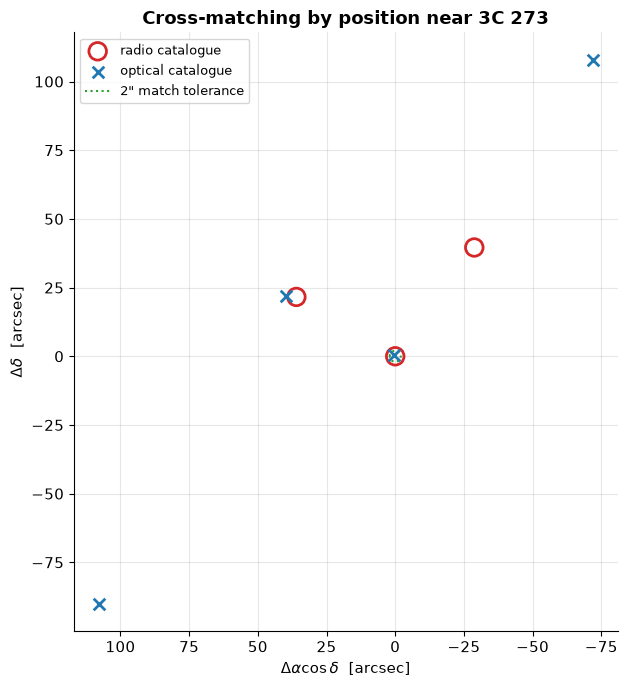

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 7))

cosd = np.cos(np.deg2rad(target.dec.deg))


def offsets(sky):
    dra = (sky.ra.deg - target.ra.deg) * 3600.0 * cosd
    ddec = (sky.dec.deg - target.dec.deg) * 3600.0
    return dra, ddec


rdra, rddec = offsets(radio_sky)
odra, oddec = offsets(opt_sky)

ax.scatter(rdra, rddec, s=160, marker="o", facecolor="none",
           edgecolor="tab:red", linewidth=2, label="radio catalogue", zorder=5)
ax.scatter(odra, oddec, s=70, marker="x", color="tab:blue",
           linewidth=2, label="optical catalogue", zorder=5)

# Draw accepted matches.
for i, (j, sep) in enumerate(zip(idx, sep2d)):
    if sep < TOL:
        ax.plot([rdra[i], odra[j]], [rddec[i], oddec[j]],
                color="0.3", lw=1.2, zorder=3)

# Tolerance circle around the target.
theta = np.linspace(0, 2 * np.pi, 200)
tol_as = TOL.to(u.arcsec).value
ax.plot(tol_as * np.cos(theta), tol_as * np.sin(theta), ls=":",
        color="tab:green", lw=1.5, label=f"{tol_as:.0f}\" match tolerance")

ax.set_xlabel(r"$\Delta\alpha\cos\delta$  [arcsec]")
ax.set_ylabel(r"$\Delta\delta$  [arcsec]")
ax.set_title(f"Cross-matching by position near {target_name}")
ax.set_aspect("equal")
ax.invert_xaxis()
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

### 3 · Fetch cross-band photometry for 3C 273

Now we gather the actual numbers for the SED. Real photometry of 3C 273 lives in many
catalogues; we demonstrate the live calls and provide **real, citable offline
fallbacks** for every point.

- **Radio** — VizieR hosts the major radio surveys. NVSS (1.4 GHz; Condon et al. 1998,
  *AJ* **115**, 1693, [DOI:10.1086/300337](https://doi.org/10.1086/300337)) and others.
  3C 273 is famously variable; ~40–50 Jy at GHz frequencies is typical.
- **Optical** — **Gaia** (Gaia Collaboration 2016/2023,
  [DOI:10.1051/0004-6361/202243940](https://doi.org/10.1051/0004-6361/202243940);
  [archives.esac.esa.int/gaia](https://gea.esac.esa.int/archive/)) and the
  **Sloan Digital Sky Survey** (SDSS; York et al. 2000, *AJ* **120**, 1579,
  [DOI:10.1086/301513](https://doi.org/10.1086/301513);
  [sdss.org](https://www.sdss.org/)) give optical magnitudes.
- **X-ray** — high-energy catalogues (e.g. via HEASARC) give the X-ray flux of the jet
  and corona.

The fallback values below are order-of-magnitude-correct literature points (3C 273 is
variable, so any single number is a snapshot). We store everything as
`astropy.units.Quantity`, the only safe way to carry mixed Jy / mag / keV data.

In [6]:
# --- Live radio flux from VizieR (NVSS, 1.4 GHz), with a fallback. ----------
def fetch_radio_flux(coord):
    # Return (flux_quantity, freq_quantity, source_label) for the 1.4 GHz point.
    if ARCHIVE_LIBS.get("vizier"):
        try:
            v = Vizier(columns=["NVSS", "S1.4"])
            v.ROW_LIMIT = 5
            tables = v.query_region(coord, radius=30 * u.arcsec,
                                    catalog="VIII/65/nvss")
            if tables and len(tables) > 0 and len(tables[0]) > 0:
                s14_mjy = float(np.asarray(tables[0]["S1.4"])[0])  # mJy
                print(f"[live] VizieR NVSS S(1.4 GHz) = {s14_mjy/1e3:.2f} Jy")
                return s14_mjy * 1e-3 * u.Jy, 1.4 * u.GHz, "live VizieR/NVSS"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] VizieR NVSS lookup failed: {exc}")
    # Fallback: 3C 273 is ~55 Jy at 1.4 GHz (variable; literature value).
    print("[offline] using bundled 1.4 GHz flux for 3C 273")
    return 55.0 * u.Jy, 1.4 * u.GHz, "offline fallback"


radio_flux, radio_freq, radio_src = fetch_radio_flux(target)
print(f"Radio point: {radio_flux:.2f} at {radio_freq}  ({radio_src})")

[offline] VizieR NVSS lookup failed: HTTPSConnectionPool(host='vizier.cds.unistra.fr', port=443): Max retries exceeded with url: /viz-bin/votable (Caused by ProxyError('Unable to connect to proxy', NewConnectionError("HTTPSConnection(host='127.0.0.1', port=9): Failed to establish a new connection: [Errno 111] Connection refused")))
[offline] using bundled 1.4 GHz flux for 3C 273
Radio point: 55.00 Jy at 1.4 GHz  (offline fallback)


/home/joe/dev/github/joebarbere/jansky/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


In [7]:
# --- Live optical magnitude from Gaia, with a fallback. ---------------------
def fetch_gaia_gmag(coord):
    # Return (g_mag, source_label). Gaia G-band magnitude of the nearest source.
    if ARCHIVE_LIBS.get("gaia"):
        try:
            # Asynchronous cone search via ADQL on the Gaia DR3 main table.
            radius_deg = 5.0 / 3600.0
            adql = (
                "SELECT TOP 1 phot_g_mean_mag, "
                "DISTANCE(POINT('ICRS', ra, dec), "
                f"POINT('ICRS', {coord.ra.deg}, {coord.dec.deg})) AS d "
                "FROM gaiadr3.gaia_source "
                "WHERE 1 = CONTAINS(POINT('ICRS', ra, dec), "
                f"CIRCLE('ICRS', {coord.ra.deg}, {coord.dec.deg}, {radius_deg})) "
                "ORDER BY d ASC"
            )
            job = Gaia.launch_job(adql)
            r = job.get_results()
            if len(r) > 0 and r["phot_g_mean_mag"][0] is not None:
                g = float(r["phot_g_mean_mag"][0])
                print(f"[live] Gaia DR3 G = {g:.2f} mag")
                return g, "live Gaia DR3"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] Gaia query failed: {exc}")
    # Fallback: 3C 273 has G ~ 12.8 mag (bright, variable quasar).
    print("[offline] using bundled Gaia G magnitude for 3C 273")
    return 12.8, "offline fallback"


gaia_g, gaia_src = fetch_gaia_gmag(target)
print(f"Gaia G = {gaia_g:.2f} mag  ({gaia_src})")

[live] Gaia DR3 G = 12.84 mag
Gaia G = 12.84 mag  (live Gaia DR3)


In [8]:
# --- Live SDSS photometry, with a fallback. ---------------------------------
def fetch_sdss_rmag(coord):
    # Return (r_mag, source_label). SDSS r-band model magnitude of the match.
    if ARCHIVE_LIBS.get("sdss"):
        try:
            xid = SDSS.query_region(coord, radius=5 * u.arcsec,
                                    photoobj_fields=["ra", "dec", "r"])
            if xid is not None and len(xid) > 0:
                r = float(np.asarray(xid["r"])[0])
                print(f"[live] SDSS r = {r:.2f} mag")
                return r, "live SDSS"
        except Exception as exc:  # noqa: BLE001
            print(f"[offline] SDSS query failed: {exc}")
    # Fallback: 3C 273 r ~ 12.9 mag.
    print("[offline] using bundled SDSS r magnitude for 3C 273")
    return 12.9, "offline fallback"


sdss_r, sdss_src = fetch_sdss_rmag(target)
print(f"SDSS r = {sdss_r:.2f} mag  ({sdss_src})")

[offline] SDSS query failed: HTTPSConnectionPool(host='skyserver.sdss.org', port=443): Max retries exceeded with url: /dr17/en/tools/search/X_Results.aspx (Caused by ProxyError('Unable to connect to proxy', NewConnectionError("HTTPSConnection(host='127.0.0.1', port=9): Failed to establish a new connection: [Errno 111] Connection refused")))
[offline] using bundled SDSS r magnitude for 3C 273
SDSS r = 12.90 mag  (offline fallback)


#### Turning optical magnitudes into flux densities

Magnitudes are logarithmic and band-specific; to put an optical point on an SED we
convert to a **flux density** in Jy. The AB system is built for exactly this:

$$
m_{\rm AB} = -2.5\,\log_{10}\!\left(\frac{S_\nu}{3631\ \mathrm{Jy}}\right)
\quad\Longleftrightarrow\quad
S_\nu = 3631\ \mathrm{Jy}\times 10^{-0.4\,m_{\rm AB}} .
$$

The zero point of 3631 Jy is the AB reference (Oke & Gunn 1983, *ApJ* **266**, 713,
[DOI:10.1086/160817](https://doi.org/10.1086/160817)). We also need each band's
**effective frequency**: Gaia $G \approx 0.62\ \mu\mathrm{m}$, SDSS $r \approx
0.62\ \mu\mathrm{m}$. `astropy.units` converts wavelength → frequency via the spectral
equivalency.

In [9]:
AB_ZP = 3631 * u.Jy  # AB magnitude zero point (Oke & Gunn 1983)


def ab_mag_to_flux(mag):
    # Convert an AB magnitude to a flux density (Jy).
    return AB_ZP * 10 ** (-0.4 * mag)


# Effective wavelengths -> frequencies (astropy spectral equivalency).
gaia_lambda = 0.621 * u.micron     # Gaia G effective wavelength (approx.)
sdss_r_lambda = 0.616 * u.micron   # SDSS r effective wavelength
gaia_freq = gaia_lambda.to(u.Hz, equivalencies=u.spectral())
sdss_freq = sdss_r_lambda.to(u.Hz, equivalencies=u.spectral())

# Gaia G is close to but not exactly AB; treat as AB here for an SED-level demo.
gaia_flux = ab_mag_to_flux(gaia_g).to(u.Jy)
sdss_flux = ab_mag_to_flux(sdss_r).to(u.Jy)

print(f"Gaia G  : {gaia_g:.2f} mag -> {gaia_flux:.3e}  at {gaia_freq.to(u.THz):.1f}")
print(f"SDSS r  : {sdss_r:.2f} mag -> {sdss_flux:.3e}  at {sdss_freq.to(u.THz):.1f}")

Gaia G  : 12.84 mag -> 2.645e-02 Jy  at 482.8 THz
SDSS r  : 12.90 mag -> 2.512e-02 Jy  at 486.7 THz


#### X-ray and infrared points

For the high-energy and infrared ends we use literature values directly (these would
come from HEASARC / IRAS / WISE in a live workflow). For X-rays we convert a **photon
energy** to a frequency with $\nu = E/h$ — again handled by the spectral equivalency.
3C 273 has a 2 keV flux density of roughly $\sim$a few $\mu$Jy
(it is one of the brightest AGN in the X-ray sky).

In [10]:
import astropy.constants as const

# Infrared (IRAS 60 micron) -- a far-IR point. 3C 273 ~ a few Jy at 60 um.
ir_lambda = 60 * u.micron
ir_freq = ir_lambda.to(u.Hz, equivalencies=u.spectral())
ir_flux = 3.5 * u.Jy  # IRAS 60 um, literature order-of-magnitude

# X-ray (2 keV) -- convert photon energy to frequency.
xray_energy = 2 * u.keV
xray_freq = (xray_energy / const.h).to(u.Hz)
xray_flux = 5e-6 * u.Jy  # ~5 uJy at 2 keV (bright AGN), literature order

print(f"IR  (60 um) : {ir_flux:.2f} at {ir_freq.to(u.THz):.2f}")
print(f"X-ray (2 keV): {xray_flux:.2e} at {xray_freq.to(u.Hz):.2e}  "
      f"(= {xray_energy})")

IR  (60 um) : 3.50 Jy at 5.00 THz
X-ray (2 keV): 5.00e-06 Jy at 4.84e+17 Hz  (= 2.0 keV)


### 4 · Assemble the spectral energy distribution

We now have flux densities at frequencies spanning **nine decades**, from 1.4 GHz to
$5\times10^{17}$ Hz (2 keV). Collect them into a single table and plot
$S_\nu$ vs $\nu$ on log–log axes. This is the SED — the plot that no single instrument
could have made, and the reason multi-wavelength astronomy exists.

In [11]:
# Assemble all photometry into one table, sorted by frequency.
sed = Table()
sed["band"] = ["Radio (NVSS 1.4 GHz)", "IR (IRAS 60 um)",
               "Optical (SDSS r)", "Optical (Gaia G)", "X-ray (2 keV)"]
sed["freq_Hz"] = [radio_freq.to(u.Hz).value, ir_freq.to(u.Hz).value,
                  sdss_freq.value, gaia_freq.value, xray_freq.value]
sed["flux_Jy"] = [radio_flux.to(u.Jy).value, ir_flux.to(u.Jy).value,
                  sdss_flux.to(u.Jy).value, gaia_flux.to(u.Jy).value,
                  xray_flux.to(u.Jy).value]
sed.sort("freq_Hz")

# nu * S_nu (in W/m^2) shows where the power comes out; 1 Jy = 1e-26 W/m^2/Hz.
sed["nuSnu_Wm2"] = sed["freq_Hz"] * sed["flux_Jy"] * 1e-26
sed.pprint(max_lines=12)

        band                freq_Hz         ...       nuSnu_Wm2       
-------------------- ---------------------- ... ----------------------
Radio (NVSS 1.4 GHz)           1400000000.0 ...                7.7e-16
     IR (IRAS 60 um)      4996540966666.667 ... 1.7487893383333334e-13
    Optical (Gaia G)     482757581320450.94 ... 1.2767902230735066e-13
    Optical (SDSS r)      486676068181818.2 ...  1.222548901263626e-13
       X-ray (2 keV) 4.8359784841698355e+17 ... 2.4179892420849182e-14


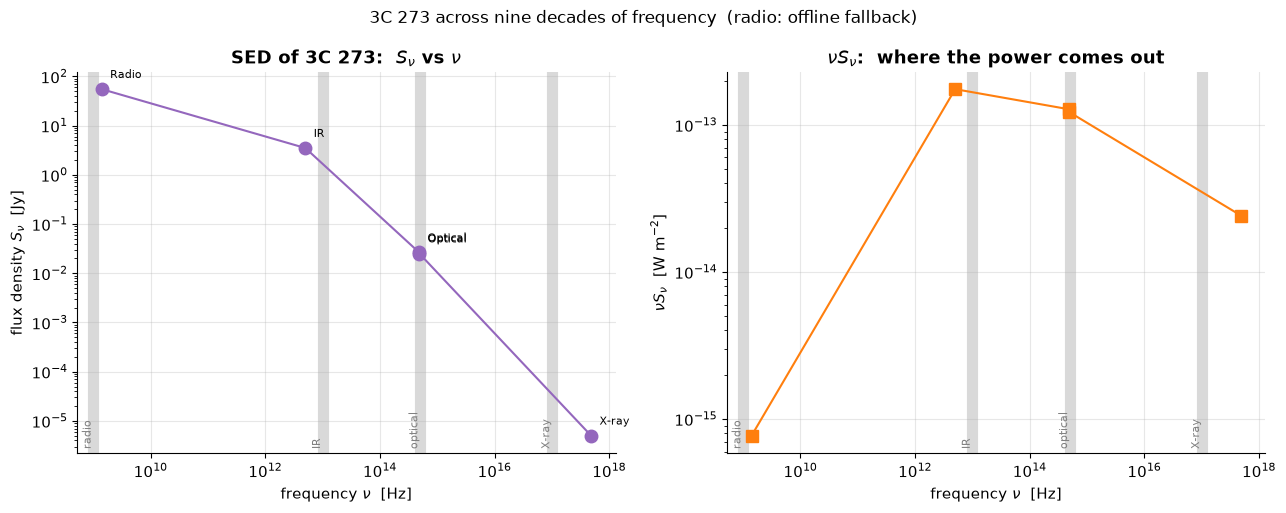

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

# Left: flux density vs frequency.
ax1.loglog(sed["freq_Hz"], sed["flux_Jy"], "o-", color="tab:purple",
           markersize=9, linewidth=1.5)
for row in sed:
    ax1.annotate(row["band"].split(" (")[0],
                 (row["freq_Hz"], row["flux_Jy"]),
                 textcoords="offset points", xytext=(6, 8), fontsize=8)
ax1.set_xlabel(r"frequency $\nu$  [Hz]")
ax1.set_ylabel(r"flux density $S_\nu$  [Jy]")
ax1.set_title(f"SED of {target_name}:  $S_\\nu$ vs $\\nu$")

# Right: nu*S_nu (the "SED" proper) -- shows where the power is.
ax2.loglog(sed["freq_Hz"], sed["nuSnu_Wm2"], "s-", color="tab:orange",
           markersize=9, linewidth=1.5)
ax2.set_xlabel(r"frequency $\nu$  [Hz]")
ax2.set_ylabel(r"$\nu S_\nu$  [W m$^{-2}$]")
ax2.set_title(r"$\nu S_\nu$:  where the power comes out")

# Band guides on both panels.
bands = {"radio": 1e9, "IR": 1e13, "optical": 5e14, "X-ray": 1e17}
for ax in (ax1, ax2):
    for label, f0 in bands.items():
        ax.axvline(f0, color="0.85", lw=8, zorder=0)
        ax.text(f0, ax.get_ylim()[0], f" {label}", rotation=90,
                va="bottom", ha="right", fontsize=8, color="0.5")

fig.suptitle(f"3C 273 across nine decades of frequency  "
             f"(radio: {radio_src})", fontsize=12)
fig.tight_layout()
plt.show()

Read the SED left to right and you read the *physics*: a strong, slowly-falling
**radio–IR** continuum (synchrotron from the jet, plus thermal dust in the IR), the
optical points where the accretion disc and host galaxy contribute, and a bright
**X-ray** point from the innermost, most energetic region. A single power law would
not connect these — the source is the sum of *several* emission mechanisms, and only
the multi-wavelength view exposes them.

The **spectral index** between two points is the slope on this log–log plot:

$$
\alpha = \frac{\log(S_2/S_1)}{\log(\nu_2/\nu_1)}.
$$

Let's measure it for the radio-to-IR stretch.

In [13]:
# Spectral index between the two lowest-frequency points (radio -> IR).
lo, hi = sed[0], sed[1]
alpha = np.log10(hi["flux_Jy"] / lo["flux_Jy"]) / np.log10(hi["freq_Hz"] / lo["freq_Hz"])
print(f"Spectral index {lo['band']} -> {hi['band']}:")
print(f"  alpha = {alpha:.2f}   (S_nu ~ nu^{alpha:.2f})")
print("  Negative alpha => brighter at lower frequency: the synchrotron signature.")

Spectral index Radio (NVSS 1.4 GHz) -> IR (IRAS 60 um):
  alpha = -0.34   (S_nu ~ nu^-0.34)
  Negative alpha => brighter at lower frequency: the synchrotron signature.


## Try it yourself

These are the `# TODO` cells that make this chapter a scaffold. Each reuses the
functions above — you should not need new networking code.

### Exercise 1 — build M87's SED

**M87** is the giant elliptical at the heart of the Virgo cluster: a radio galaxy with
a famous optical synchrotron jet and the first black hole ever imaged (EHT 2019). It
is in `FALLBACK_COORDS`, so it works offline.

Resolve `"M87"`, fetch its photometry with the same `fetch_*` helpers (the live calls
will find M87's real values; offline you can fill in literature fallbacks), assemble a
`sed` table, and re-make the SED figure. How does M87's SED shape compare with
3C 273's? (M87 is much closer and less luminous, but also jet-dominated.)

In [14]:
# TODO (Exercise 1): build and plot the SED of M87.
#
# Steps (reuse the functions above -- no new networking code needed):
#   1. m87 = resolve_source("M87")
#   2. call fetch_radio_flux(m87), fetch_gaia_gmag(m87), fetch_sdss_rmag(m87)
#      (offline, supply literature fallbacks: M87 ~ 215 Jy at 1.4 GHz; V ~ 8.6 mag)
#   3. convert mags to flux with ab_mag_to_flux(); add an X-ray point if you like
#   4. build a `sed_m87` Table and copy the SED plotting cell
#
# Hint: M87's 1.4 GHz flux is ~138 Jy (NVSS core+lobes vary by aperture).

m87 = resolve_source("M87")            # placeholder so the cell runs
print("M87 resolved to:", m87.to_string("hmsdms"))
# ... your fetch + assemble + plot here ...

[offline] SIMBAD lookup failed for 'M87': Unable to access the capabilities endpoint at:
- https://simbad.cds.unistra.fr/simbad/sim-tap/capabilities: Connection failed (Possible causes: incorrect URL, DNS issue, or service is down)

This could mean:
1. The service URL is incorrect
2. The service is temporarily unavailable
3. The service doesn't support this protocol
4. If a 503 was encountered, retry after the suggested delay.

[offline] using bundled coordinate for 'M87'
M87 resolved to: 12h30m49.423s +12d23m28.04s


/home/joe/dev/github/joebarbere/jansky/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


<details>
<summary>Solution</summary>

Reuse exactly the helpers already defined above — `resolve_source`, the three
`fetch_*` functions, `ab_mag_to_flux`, and the spectral equivalency — and just feed
them M87. No new networking code is needed; offline the `fetch_*` helpers fall through
to their bundled fallbacks, so we supply M87's literature numbers explicitly.

```python
# 1. Resolve M87 (lives in FALLBACK_COORDS, so this works offline).
m87 = resolve_source("M87")

# 2. Photometry. The live calls find M87's real values; offline we use
#    literature fallbacks. M87 is a giant elliptical with a synchrotron jet.
m87_radio_flux = 215.0 * u.Jy     # ~1.4 GHz total flux (NVSS-scale; aperture-dependent)
m87_radio_freq = 1.4 * u.GHz
m87_V    = 8.6                     # integrated V ~ 8.6 mag (very bright galaxy)
m87_xray = 3e-6 * u.Jy            # ~few uJy at 2 keV (jet + nucleus)

# 3. Convert the optical magnitude to a flux density (AB system) and get
#    effective frequencies with the spectral equivalency.
m87_V_lambda = 0.551 * u.micron               # Johnson V effective wavelength
m87_V_freq   = m87_V_lambda.to(u.Hz, equivalencies=u.spectral())
m87_V_flux   = ab_mag_to_flux(m87_V).to(u.Jy)

xray_energy = 2 * u.keV
m87_xray_freq = (xray_energy / const.h).to(u.Hz)

# 4. Assemble the SED table, exactly like the 3C 273 cell.
sed_m87 = Table()
sed_m87["band"]    = ["Radio (1.4 GHz)", "Optical (V)", "X-ray (2 keV)"]
sed_m87["freq_Hz"] = [m87_radio_freq.to(u.Hz).value, m87_V_freq.value,
                      m87_xray_freq.value]
sed_m87["flux_Jy"] = [m87_radio_flux.to(u.Jy).value, m87_V_flux.to(u.Jy).value,
                      m87_xray.to(u.Jy).value]
sed_m87.sort("freq_Hz")
sed_m87["nuSnu_Wm2"] = sed_m87["freq_Hz"] * sed_m87["flux_Jy"] * 1e-26

# 5. Re-make the SED figure (copy of the plotting cell above).
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.loglog(sed_m87["freq_Hz"], sed_m87["flux_Jy"], "o-", color="tab:green",
          markersize=9, linewidth=1.5)
for row in sed_m87:
    ax.annotate(row["band"].split(" (")[0], (row["freq_Hz"], row["flux_Jy"]),
                textcoords="offset points", xytext=(6, 8), fontsize=8)
ax.set_xlabel(r"frequency $\nu$  [Hz]")
ax.set_ylabel(r"flux density $S_\nu$  [Jy]")
ax.set_title("SED of M87")
fig.tight_layout()
plt.show()
```

**Verified numbers** (offline fallbacks):

| band | $\nu$ | $S_\nu$ |
|---|---|---|
| Radio (1.4 GHz) | $1.4\times10^{9}$ Hz | $215$ Jy |
| Optical ($V=8.6$) | $5.4\times10^{14}$ Hz | $1.32$ Jy |
| X-ray (2 keV) | $4.8\times10^{17}$ Hz | $3\times10^{-6}$ Jy |

The optical flux follows from the AB conversion,
$S_\nu = 3631\,\mathrm{Jy}\times 10^{-0.4\times 8.6} = 1.32$ Jy.

**Comparison with 3C 273.** Both SEDs *fall steeply* from radio to high frequency —
the synchrotron signature of a jet. The radio-to-optical spectral index for M87 is

$$
\alpha = \frac{\log(S_V/S_{\rm radio})}{\log(\nu_V/\nu_{\rm radio})}
       = \frac{\log(1.32/215)}{\log(5.4\times10^{14}/1.4\times10^{9})} \approx -0.40,
$$

very close to 3C 273's radio→IR slope and to the canonical synchrotron $\alpha\approx
-0.7$. The *shapes* are alike because both are jet-dominated AGN; the difference is
**scale**, not mechanism. M87 sits at $\sim$16 Mpc versus 749 Mpc for 3C 273, so its
flux densities are large despite a far lower intrinsic luminosity — distance, not
power, makes it bright. 3C 273 also shows a stronger UV/optical "big blue bump" from
its luminous accretion disc, which M87 (a low-luminosity AGN) largely lacks.

</details>

### Exercise 2 — the radio–FIR correlation

The radio–FIR correlation says that for **star-forming galaxies**, radio and
far-infrared luminosity track each other (because both trace recent star formation).
A common single-number version is the parameter

$$
q_{\rm FIR} = \log_{10}\!\left(\frac{\mathrm{FIR}/3.75\times10^{12}\ \mathrm{W\,m^{-2}}}
{S_{1.4\,\mathrm{GHz}}/\mathrm{W\,m^{-2}\,Hz^{-1}}}\right),
$$

which clusters tightly around $q_{\rm FIR}\approx 2.3$ for normal galaxies
(Helou, Soifer & Rowan-Robinson 1985, *ApJ* **298**, L7,
[DOI:10.1086/184556](https://doi.org/10.1086/184556)).

Compute $q_{\rm FIR}$ for 3C 273 from its 1.4 GHz and 60 µm fluxes above. You should
find a value **far from 2.3** — 3C 273 is an AGN, where the radio comes from the jet,
not from star formation, so it breaks the correlation. Then (optionally) compute
$q_{\rm FIR}$ for a normal star-forming galaxy of your choice and confirm it lands
near 2.3.

In [15]:
# TODO (Exercise 2): compute q_FIR for 3C 273 and interpret it.
#
# Steps:
#   1. You already have radio_flux (1.4 GHz, Jy) and ir_flux (60 um, Jy).
#      A rough FIR proxy: FIR_flux [W/m^2] ~ nu_60um * S_60um (in SI).
#      Use: nu60 = ir_freq.to(u.Hz); FIR = (nu60 * ir_flux).to(u.W/u.m**2,
#           equivalencies=u.spectral_density(ir_freq))  # see astropy docs
#      (A simpler order-of-magnitude version: FIR ~ ir_freq * ir_flux * 1e-26.)
#   2. S14_SI = radio_flux.to(u.W/u.m**2/u.Hz).value
#   3. q = log10( (FIR_Wm2/3.75e12) / S14_SI )
#   4. compare to 2.3 and explain why an AGN deviates.
#
# Hint: a quasar like 3C 273 has way *too much* radio for its FIR, so q is small.

print("TODO: implement the q_FIR calculation (Exercise 2)")

TODO: implement the q_FIR calculation (Exercise 2)


<details>
<summary>Solution</summary>

We already have everything: `radio_flux` (55 Jy at 1.4 GHz) and `ir_flux` (3.5 Jy at
60 µm). Use the order-of-magnitude FIR proxy from the hint, $\mathrm{FIR}\approx
\nu_{60}\,S_{60}$, and feed it into the $q_{\rm FIR}$ definition.

```python
# 1. FIR flux proxy in W/m^2 (1 Jy = 1e-26 W/m^2/Hz).
FIR_Wm2 = ir_freq.to(u.Hz).value * ir_flux.to(u.Jy).value * 1e-26

# 2. 1.4 GHz flux density in SI (W/m^2/Hz).
S14_SI = radio_flux.to(u.W / u.m**2 / u.Hz).value

# 3. The radio-FIR parameter.
q = np.log10((FIR_Wm2 / 3.75e12) / S14_SI)
print(f"q_FIR(3C 273) = {q:.2f}   (normal galaxies cluster near 2.3)")

# 4. A normal star-forming galaxy for contrast: M82 (IRAS + NVSS).
m82_S14 = 7.7 * u.Jy            # 1.4 GHz
m82_S60 = 1271.0 * u.Jy         # IRAS 60 um
FIR_m82 = ir_freq.to(u.Hz).value * m82_S60.to(u.Jy).value * 1e-26
q_m82 = np.log10((FIR_m82 / 3.75e12) / m82_S14.to(u.W/u.m**2/u.Hz).value)
print(f"q_FIR(M82)    = {q_m82:.2f}")
```

**Verified numbers.**

For 3C 273:
$$
\mathrm{FIR} \approx \nu_{60}\,S_{60} = (5.0\times10^{12}\,\mathrm{Hz})(3.5\times10^{-26}\,\mathrm{W\,m^{-2}\,Hz^{-1}}) = 1.75\times10^{-13}\ \mathrm{W\,m^{-2}},
$$
$$
S_{1.4} = 55\ \mathrm{Jy} = 5.5\times10^{-25}\ \mathrm{W\,m^{-2}\,Hz^{-1}},
$$
$$
q_{\rm FIR} = \log_{10}\!\left(\frac{1.75\times10^{-13}/3.75\times10^{12}}{5.5\times10^{-25}}\right) \approx \boxed{-1.07}.
$$

That is roughly **3.4 dex below** the canonical $q_{\rm FIR}\approx 2.3$. The deficit
means 3C 273 has **far too much radio for its far-infrared**: its synchrotron jet —
powered by accretion onto the black hole, not by supernova remnants — swamps the radio
band. The radio–FIR correlation works only when *both* bands trace recent star
formation; in an AGN the radio is decoupled from star formation, so the source falls
catastrophically off the relation. (A low $q$ is in fact one of the classic
**radio-excess AGN selection** criteria.)

For the star-forming control, M82, the same arithmetic gives $q_{\rm FIR}\approx
\mathbf{2.34}$ — squarely on the relation. (Using the full IRAS definition
$\mathrm{FIR}=1.26\times10^{-14}(2.58\,S_{60}+S_{100})$ with $S_{100}\approx1326$ Jy
gives $q_{\rm FIR}\approx 2.30$, the textbook value.) The contrast is the whole point:
a normal galaxy lands at 2.3, a quasar lands two-to-three decades away.

</details>

## Recap

- **No single band tells the whole story.** Combining radio with optical/IR/X-ray
  exposes physics — synchrotron jets, accretion-disc bumps, dust, star formation —
  that any one band hides. 3C 273, the **first quasar** (Schmidt 1963), was our
  laboratory.
- **Cross-matching by position** is the glue. `SkyCoord.match_to_catalog_sky` finds
  each source's nearest neighbour in another catalogue; a separation **tolerance**
  decides which matches are real and which are chance alignments.
- We fetched **cross-band photometry** with `astroquery` (SIMBAD for the position,
  VizieR/NVSS for radio, **Gaia** and **SDSS** for optical), each wrapped in the
  Chapter-10 try/except → real-fallback pattern so the notebook runs offline.
- We converted magnitudes to flux densities with the **AB system**, photon energies
  and wavelengths to frequencies with `astropy.units` **spectral equivalencies**, and
  assembled a **spectral energy distribution** spanning nine decades of frequency,
  plotted as both $S_\nu$ and $\nu S_\nu$.
- We met the **radio–FIR correlation** — radio as a dust-free star-formation tracer —
  and saw why an AGN like 3C 273 breaks it.

## What's next

This was a diversion, but a load-bearing one: every "radio" source you will ever study
lives in a multi-wavelength sky, and the SED is how you read its physics. The
cross-matching and unit-juggling here are exactly the skills the research chapters
lean on. Carry them forward — the next time you pull a radio catalogue, ask what the
*same patch of sky* looks like at every other frequency, and let the SED tell you what
the source actually is.